<a href="https://colab.research.google.com/github/EllenEufrasio/Algoritmos_e_Logicas_de_Programacao/blob/main/introducao_pln.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nome: Ellen Eufrasio de Oliveira
RA: 1131392413021

# Sessão 02 — Primeiro contato com PLN em Python

**Processamento de Linguagem Natural**

Bloco de atividade (2 aulas) da sessão 02. Objetivo: sair deste notebook tendo tokenizado seu primeiro texto em português e entendido, na prática, por que "quebrar" um texto em palavras não é tão trivial quanto parece.

Leva menos de uma hora. Não precisa saber nada de PLN ainda — é só o primeiro contato.

## 1. Aquecendo com strings em Python

Antes de usar qualquer biblioteca de PLN, vale relembrar o que o Python puro já sabe fazer com texto — porque é exatamente daqui que a tokenização "por baixo dos panos" começa.

In [8]:
frase = "  Processamento de Linguagem Natural é incrível!  "

print(frase.lower())          # tudo minúsculo
print(frase.strip())          # tira espaços do início/fim
print(frase.replace("!", "")) # troca (ou remove) um trecho
print(len(frase))             # quantos caracteres tem
print(frase[2:16])            # fatiar (slicing): do caractere 2 até o 15

  processamento de linguagem natural é incrível!  
Processamento de Linguagem Natural é incrível!
  Processamento de Linguagem Natural é incrível  
50
Processamento 


Uma string também é uma sequência — dá pra fatiar (`frase[2:16]`) e, mais importante pra hoje, dá pra **quebrar em pedaços** com `.split()`. Isso já é, no fundo, uma primeira tentativa de tokenização.

In [9]:
frase_simples = "Python é uma linguagem de programação"
print(frase_simples.split())

['Python', 'é', 'uma', 'linguagem', 'de', 'programação']


Funcionou bem — pra essa frase. Mas repare o que acontece com uma frase mais realista, com pontuação:

In [10]:
frase_real = "PLN é incrível! Mas também é desafiador, não é mesmo?"
print(frase_real.split())

['PLN', 'é', 'incrível!', 'Mas', 'também', 'é', 'desafiador,', 'não', 'é', 'mesmo?']


Repare que a pontuação ficou grudada nas palavras (`"incrível!"`, `"mesmo?"`) — `.split()` só separa por espaço, não sabe nada sobre gramática. É exatamente esse tipo de problema que uma biblioteca feita para PLN resolve. Vamos ver como.

### Indexação, com mais detalhe

Cada caractere de uma string tem uma posição — inclusive de trás pra frente, com índice negativo:

In [11]:
s = "Fatec Mauá"

print(s[0])    # primeiro caractere
print(s[1])    # segundo caractere
print(s[-1])   # último caractere (índice negativo)
print(s[:-1])  # tudo, menos o último caractere

F
a
á
Fatec Mau


O `:` do slicing também aceita um terceiro número — o passo. Passo `-1` é um jeito rápido de inverter a string inteira:

In [12]:
print(s[::1])   # passo 1 — igual ao original, sem pular nada
print(s[::2])   # passo 2 — pula um caractere a cada vez
print(s[::-1])  # passo -1 — percorre de trás pra frente: inverte a string

Fatec Mauá
FtcMu
áuaM cetaF


Duas strings também se combinam com operadores que você já conhece de número: `+` junta (concatena) duas strings numa só, e `*` repete uma string várias vezes. Isso é muito usado, por exemplo, pra montar uma linha separadora ou juntar nome e sobrenome:

In [13]:
curso = "Processamento de Linguagem Natural"

print(s + " — " + curso)  # + concatena (junta) as strings

separador = "-" * 20      # * repete a string 20 vezes
print(separador)

Fatec Mauá — Processamento de Linguagem Natural
--------------------


### Mais funções prontas de string

Além de `.lower()`, `.strip()` e `.replace()` que você já viu, o Python tem várias outras funções embutidas pra responder perguntas sobre uma string — muitas delas devolvem `True`/`False` (perguntas de sim ou não) ou uma posição/contagem:

In [14]:
frase = "seja bem vindo ao universo de python"

print(frase.capitalize())    # deixa só a primeira letra maiúscula
print(frase.count("o"))      # conta quantas vezes "o" aparece
print(frase.find("python"))  # em que posição "python" começa (-1 se não achar)
print(frase.isalpha())       # é feita só de letras, sem espaço nem número?
print(frase.islower())       # está toda em minúsculo?
print(frase.endswith("n"))   # termina com "n"?

Seja bem vindo ao universo de python
4
30
False
True
True


Repare que `frase.isalpha()` deu `False` — a frase inteira tem espaços entre as palavras, e espaço não é letra. `.isalpha()` só devolve `True` quando *todos* os caracteres da string são letras, sem exceção. Guarde essa ideia: é exatamente o que vamos usar mais tarde pra filtrar pontuação de uma lista de tokens.

### Comparando strings

Strings também podem ser comparadas com `==`, igual números — e maiúsculo/minúsculo faz diferença:

In [15]:
print("Python" == "python")  # False — maiúscula/minúscula importa na comparação
print("Python" == "Python")  # True — idênticas

False
True


## 2. Preparando o ambiente

Vamos usar o `NLTK` (Natural Language Toolkit), a biblioteca mais didática de PLN em Python. Se estiver rodando no Google Colab, o NLTK já vem instalado; se estiver na sua máquina, rode a célula abaixo uma vez.

In [16]:
# Se necessário, descomente a linha abaixo para instalar o NLTK
!pip install nltk

import nltk

# Baixa os recursos usados para tokenizar (só precisa rodar uma vez por máquina)
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 3. Nosso primeiro texto

Vamos trabalhar com uma avaliação de produto em português — o mesmo tipo de texto que você vai ver de novo lá na frente, quando chegarmos em análise de sentimento.

In [17]:
texto = (
    "Comprei esse fone de ouvido semana passada e, sinceramente, não esperava tanto. "
    "A bateria dura o dia inteiro, o som é ótimo pra esse preço e o app conectou super rápido. "
    "Só achei a caixinha um pouco frágil, mas isso não estragou minha experiência. Recomendo!"
)

print(texto)

Comprei esse fone de ouvido semana passada e, sinceramente, não esperava tanto. A bateria dura o dia inteiro, o som é ótimo pra esse preço e o app conectou super rápido. Só achei a caixinha um pouco frágil, mas isso não estragou minha experiência. Recomendo!


## 4. Segmentação de sentenças

Antes de quebrar em palavras, vamos quebrar em frases. Parece simples ("é só separar pelo ponto final"), mas repare que o texto tem abreviações e números — um separador ingênuo por `.` erraria em vários lugares reais (ex.: "Sr.", "3.5", "www.site.com").

In [18]:
from nltk.tokenize import sent_tokenize

sentencas = sent_tokenize(texto, language='portuguese')

for i, s in enumerate(sentencas, start=1):
    print(f"{i}. {s}")

1. Comprei esse fone de ouvido semana passada e, sinceramente, não esperava tanto.
2. A bateria dura o dia inteiro, o som é ótimo pra esse preço e o app conectou super rápido.
3. Só achei a caixinha um pouco frágil, mas isso não estragou minha experiência.
4. Recomendo!


## 5. Tokenização de palavras

Agora quebramos cada sentença em tokens (palavras e pontuação separadas), com uma ferramenta feita pra isso — repare como ela lida melhor com a pontuação do que o `.split()` lá de cima. Note também como "não", "é" e a pontuação viram itens próprios da lista — isso é o tipo de detalhe que vamos aprender a tratar (ou não) na sessão 3.

*Isso é literalmente o nível mais básico da "hierarquia da compreensão" que vimos no material teórico — o nível morfológico: decidir quais são as unidades (as palavras) antes de qualquer análise mais profunda.*

In [19]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(texto, language='portuguese')

print(f"Total de tokens: {len(tokens)}")
print(tokens)



Total de tokens: 53
['Comprei', 'esse', 'fone', 'de', 'ouvido', 'semana', 'passada', 'e', ',', 'sinceramente', ',', 'não', 'esperava', 'tanto', '.', 'A', 'bateria', 'dura', 'o', 'dia', 'inteiro', ',', 'o', 'som', 'é', 'ótimo', 'pra', 'esse', 'preço', 'e', 'o', 'app', 'conectou', 'super', 'rápido', '.', 'Só', 'achei', 'a', 'caixinha', 'um', 'pouco', 'frágil', ',', 'mas', 'isso', 'não', 'estragou', 'minha', 'experiência', '.', 'Recomendo', '!']


## 6. Quais palavras mais aparecem?

Vamos contar a frequência de cada token. Antes de rodar, tente prever: quais palavras você acha que vão aparecer mais nesse texto?

In [20]:
from collections import Counter

# Normalizamos para minúsculas antes de contar, senão "O" e "o" contariam como palavras diferentes

tokens_normalizados = [t.lower() for t in tokens]
print(tokens_normalizados)

frequencia = Counter(tokens_normalizados)
frequencia


['comprei', 'esse', 'fone', 'de', 'ouvido', 'semana', 'passada', 'e', ',', 'sinceramente', ',', 'não', 'esperava', 'tanto', '.', 'a', 'bateria', 'dura', 'o', 'dia', 'inteiro', ',', 'o', 'som', 'é', 'ótimo', 'pra', 'esse', 'preço', 'e', 'o', 'app', 'conectou', 'super', 'rápido', '.', 'só', 'achei', 'a', 'caixinha', 'um', 'pouco', 'frágil', ',', 'mas', 'isso', 'não', 'estragou', 'minha', 'experiência', '.', 'recomendo', '!']


Counter({'comprei': 1,
         'esse': 2,
         'fone': 1,
         'de': 1,
         'ouvido': 1,
         'semana': 1,
         'passada': 1,
         'e': 2,
         ',': 4,
         'sinceramente': 1,
         'não': 2,
         'esperava': 1,
         'tanto': 1,
         '.': 3,
         'a': 2,
         'bateria': 1,
         'dura': 1,
         'o': 3,
         'dia': 1,
         'inteiro': 1,
         'som': 1,
         'é': 1,
         'ótimo': 1,
         'pra': 1,
         'preço': 1,
         'app': 1,
         'conectou': 1,
         'super': 1,
         'rápido': 1,
         'só': 1,
         'achei': 1,
         'caixinha': 1,
         'um': 1,
         'pouco': 1,
         'frágil': 1,
         'mas': 1,
         'isso': 1,
         'estragou': 1,
         'minha': 1,
         'experiência': 1,
         'recomendo': 1,
         '!': 1})

In [21]:
frequencia = Counter(tokens_normalizados)

for palavra, contagem in frequencia.most_common(10):
   print(f"{palavra!r}: {contagem}")

',': 4
'.': 3
'o': 3
'esse': 2
'e': 2
'não': 2
'a': 2
'comprei': 1
'fone': 1
'de': 1


Repare que o topo da lista tem dois tipos de "ruído" bem diferentes, que **não** são a mesma coisa:

- **Pontuação** — `,` e `.`. Não são palavras, são separadores que a tokenização manteve como itens da lista.
- **Palavras funcionais muito frequentes** — "o", "e", "a". Essas sim são *stopwords*: palavras que aparecem em praticamente qualquer texto em português e dizem pouco sobre o *conteúdo* dele.

São dois problemas diferentes, com soluções diferentes: pontuação a gente filtra (por exemplo, mantendo só tokens alfabéticos), stopwords a gente remove com uma lista pronta. Vamos tratar os dois na sessão 3.

## 7. Visualizando a frequência

Um gráfico simples ajuda a enxergar o padrão.

In [22]:
!pip install matplotlib

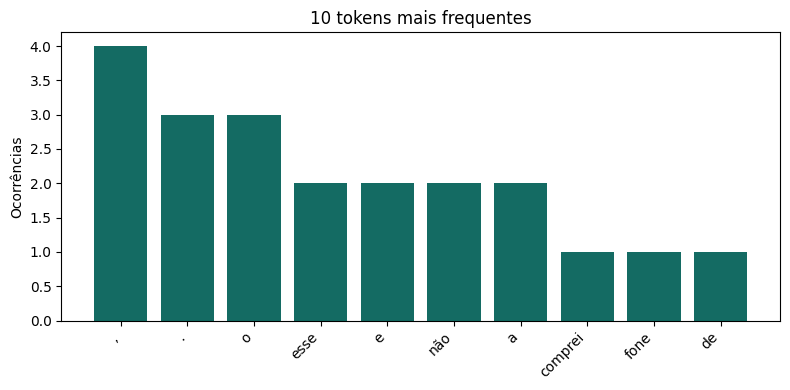

In [23]:

import matplotlib.pyplot as plt

mais_comuns = frequencia.most_common(10)
palavras = [p for p, _ in mais_comuns]
contagens = [c for _, c in mais_comuns]

plt.figure(figsize=(8, 4))
plt.bar(palavras, contagens, color='#146B63')
plt.title('10 tokens mais frequentes')
plt.ylabel('Ocorrências')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Dicas, se travar:**
> - Para pontuação: existe uma forma de perguntar "esse token é feito só de letras?" para cada item — pesquise `str.isalpha()` em Python.
> - Para stopwords: você não precisa escrever a lista de palavras vazias na mão — o NLTK já tem uma pronta para português, em `nltk.corpus.stopwords`.
> - No fim, as duas soluções são a mesma ideia: montar uma nova lista de tokens que só inclui quem "passa no teste", e só depois contar a frequência dela.
>
> A implementação completa a gente faz junto na sessão 3 — aqui o objetivo é só chegar perto da ideia sozinho(a).

In [24]:
teste = 'olá eu tenho 20 anos e tenho 1,75m de altura. Meu peso é 70kg e meu IMC é 22,9. Meu CPF é 123.456.789-00 e meu RG é 12.345.678-9. crito senhor pai nosso. santo senhor. jesus cristo. dei-me paciencia'

In [25]:
teste

'olá eu tenho 20 anos e tenho 1,75m de altura. Meu peso é 70kg e meu IMC é 22,9. Meu CPF é 123.456.789-00 e meu RG é 12.345.678-9. crito senhor pai nosso. santo senhor. jesus cristo. dei-me paciencia'

In [26]:
print(teste)

olá eu tenho 20 anos e tenho 1,75m de altura. Meu peso é 70kg e meu IMC é 22,9. Meu CPF é 123.456.789-00 e meu RG é 12.345.678-9. crito senhor pai nosso. santo senhor. jesus cristo. dei-me paciencia


In [27]:
teste2 = '''olá eu tenho 20 anos e tenho 1,75m de altura. Meu peso é 70kg e meu IMC é 22,9. Meu CPF é 123.456.789-00 e meu RG é 12.345.678-9.
crito senhor pai nosso.
santo senhor
jesus cristo
dei-me paciencia.'''
print(teste2)

olá eu tenho 20 anos e tenho 1,75m de altura. Meu peso é 70kg e meu IMC é 22,9. Meu CPF é 123.456.789-00 e meu RG é 12.345.678-9.
crito senhor pai nosso.
santo senhor
jesus cristo
dei-me paciencia.


In [28]:
print(teste2)

olá eu tenho 20 anos e tenho 1,75m de altura. Meu peso é 70kg e meu IMC é 22,9. Meu CPF é 123.456.789-00 e meu RG é 12.345.678-9.
crito senhor pai nosso.
santo senhor
jesus cristo
dei-me paciencia.


In [58]:
str.isalpha(teste)

False

In [30]:
testeTrue= 'olá'

#Note: Para que a função str.isalpha retorne True, a string deve ser 'tokenizada', pois se houver algum espaço na string, ela irá retornar False

In [59]:
str.isalpha(testeTrue)

True

> ## Lembre

> E se depois que você tokenizar o texto verificar se ele é de fato uma letra? caso for um ponto, número ou interrogação por exemplo, você pode ignorar.






In [32]:
nltk.download('stopwords')
print(nltk.corpus.stopwords.words('portuguese'))

stop = nltk.corpus.stopwords.words('portuguese')

['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'é', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'éramos', 'essa', 'essas', 'esse', 'esses', 'esta', 'está', 'estamos', 'estão', 'estar', 'estas', 'estava', 'estavam', 'estávamos', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estivéramos', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéssemos', 'estou', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'fôramos', 'forem', 'formos', 'fosse', 'fossem', 'fôssemos', 'fui', 'há', 'haja', 'hajam', 'hajamos', 'hão', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houverá', 'houveram', 'houvéramos', 'houverão', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houveríamos', 'houvermos', 'houvesse', 'houvessem', 'houvésse

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print(stop)

['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'é', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'éramos', 'essa', 'essas', 'esse', 'esses', 'esta', 'está', 'estamos', 'estão', 'estar', 'estas', 'estava', 'estavam', 'estávamos', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estivéramos', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéssemos', 'estou', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'fôramos', 'forem', 'formos', 'fosse', 'fossem', 'fôssemos', 'fui', 'há', 'haja', 'hajam', 'hajamos', 'hão', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houverá', 'houveram', 'houvéramos', 'houverão', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houveríamos', 'houvermos', 'houvesse', 'houvessem', 'houvésse

> #### E se você quiser excluir essas palavras, para que elas não sejam contadas como frequentes? como você faria?



## 8. Sua vez

Troque a variável `texto` da seção 3 por um parágrafo curto escrito por você (ou copiado de uma notícia, rede social, etc. — em português) e rode as células de novo.

**Entregue como atividade (2–3 frases cada resposta, na célula de markdown abaixo):**

1. Alguma palavra foi tokenizada de um jeito que te surpreendeu? Qual e por quê?

**Resposta:** Não houve nenhuma palavra que ao ser tokenizada me surpreendeu, acredito que isso aconteceu por ser um texto simples, sem caracter especial, emoji e etc.
Porém, como teste adicionei um cifrão na frente de uma palavra sem espaço, e ao ser tokenizada ela foi separada, retornando cifrão, "infantil", mesmo que no texto estava "$infantil"

2. Se você tivesse que apagar as palavras menos úteis da lista de frequência antes de analisar o *assunto* do texto, quais tiraria primeiro?

**Resposta:** Tiraria as preposições e pontuações, como virgulas, dois pontos e pontos finais.

3. Pensando na lista de frequência da seção 6: como você faria, em código, para tirar a pontuação e as stopwords antes de contar? Não precisa implementar — descreva a ideia. Dica: o que você perguntaria sobre cada token para decidir se ele fica ou sai da lista?

**Resposta:** Para tirar a pontuação e as stopwords, primeiro eu criaria uma lista de tokens normalizados (em minúsculas), como já feito. Em seguida, eu faria duas etapas de filtragem:

1.  **Remoção de Stopwords:** Para cada token na lista normalizada, eu verificaria se ele está presente na lista de stopwords pré-definida do NLTK para português (`nltk.corpus.stopwords.words('portuguese')`). Se o token **não** estiver na lista de stopwords, ele seria mantido.
2.  **Remoção de Pontuação e Números:** Para os tokens que sobraram após a remoção das stopwords, eu verificaria se cada token é composto **apenas por letras** usando o método `str.isalpha()`. Se `str.isalpha()` retornar `True`, o token seria considerado uma palavra válida; caso contrário (se contiver números, símbolos ou for apenas pontuação), ele seria descartado.

Depois dessas duas etapas de filtragem, a lista resultante conteria apenas as palavras relevantes, e então a frequência poderia ser contada para entender o assunto do texto de forma mais eficaz.

## Então agora é com você!!

RESOLUÇÃO DO EXERCÍCIO 1

In [33]:
meu_texto ='''Trabalho in$fantil: 1,6 milhão de crianças e adolescentes estavam nessa situação no Brasil em 2024
Entre 2016 e 2024, o trabalho $infantil caiu no país e, em 2024, o número de crianças e adolescentes em atividades de maior risco teve o menor patamar já registrado, mas ainda são 560 mil nessa situação.
Em 2024, o trabalho infantil fazia parte da realidade de mais de um 1,6 milhão de crianças e adolescentes de 5 a 17 anos no país. 34 mil jovens a mais do que em 2023. '''

print(meu_texto)

meus_tokens = word_tokenize(meu_texto, language='portuguese')
print("\nMeus tokens: ", meus_tokens)

from nltk.tokenize import word_tokenize

tokens = word_tokenize(meu_texto, language='portuguese')

print(f"\nTotal de tokens: {len(tokens)}")
print("\n", tokens)

# Por que usar a função t.lower? Realizamos essa normalização para minúsculas antes de contar, senão "O" e "o" contariam como palavras diferentes
meus_tokens = [t.lower() for t in meus_tokens]
print("\nMeus tokens tratados: ", meus_tokens)

frequencia = Counter(meus_tokens)
print("\n", frequencia)

Trabalho in$fantil: 1,6 milhão de crianças e adolescentes estavam nessa situação no Brasil em 2024
Entre 2016 e 2024, o trabalho $infantil caiu no país e, em 2024, o número de crianças e adolescentes em atividades de maior risco teve o menor patamar já registrado, mas ainda são 560 mil nessa situação.
Em 2024, o trabalho infantil fazia parte da realidade de mais de um 1,6 milhão de crianças e adolescentes de 5 a 17 anos no país. 34 mil jovens a mais do que em 2023. 

Meus tokens:  ['Trabalho', 'in', '$', 'fantil', ':', '1,6', 'milhão', 'de', 'crianças', 'e', 'adolescentes', 'estavam', 'nessa', 'situação', 'no', 'Brasil', 'em', '2024', 'Entre', '2016', 'e', '2024', ',', 'o', 'trabalho', '$', 'infantil', 'caiu', 'no', 'país', 'e', ',', 'em', '2024', ',', 'o', 'número', 'de', 'crianças', 'e', 'adolescentes', 'em', 'atividades', 'de', 'maior', 'risco', 'teve', 'o', 'menor', 'patamar', 'já', 'registrado', ',', 'mas', 'ainda', 'são', '560', 'mil', 'nessa', 'situação', '.', 'Em', '2024', ',',

In [34]:
import nltk
from nltk.corpus import stopwords

stop = nltk.corpus.stopwords.words('portuguese')

# Tokenizar o texto (dividir em palavras)
tokens = nltk.word_tokenize(meu_texto, language='portuguese')

# Filtrar removendo as stopwords
tokens_sem_stopwords = [palavra for palavra in tokens if palavra.lower() not in stop]

print("Tokens originais:", tokens)
print("Tokens sem stopwords:", tokens_sem_stopwords)


Tokens originais: ['Trabalho', 'in', '$', 'fantil', ':', '1,6', 'milhão', 'de', 'crianças', 'e', 'adolescentes', 'estavam', 'nessa', 'situação', 'no', 'Brasil', 'em', '2024', 'Entre', '2016', 'e', '2024', ',', 'o', 'trabalho', '$', 'infantil', 'caiu', 'no', 'país', 'e', ',', 'em', '2024', ',', 'o', 'número', 'de', 'crianças', 'e', 'adolescentes', 'em', 'atividades', 'de', 'maior', 'risco', 'teve', 'o', 'menor', 'patamar', 'já', 'registrado', ',', 'mas', 'ainda', 'são', '560', 'mil', 'nessa', 'situação', '.', 'Em', '2024', ',', 'o', 'trabalho', 'infantil', 'fazia', 'parte', 'da', 'realidade', 'de', 'mais', 'de', 'um', '1,6', 'milhão', 'de', 'crianças', 'e', 'adolescentes', 'de', '5', 'a', '17', 'anos', 'no', 'país', '.', '34', 'mil', 'jovens', 'a', 'mais', 'do', 'que', 'em', '2023', '.']
Tokens sem stopwords: ['Trabalho', 'in', '$', 'fantil', ':', '1,6', 'milhão', 'crianças', 'adolescentes', 'nessa', 'situação', 'Brasil', '2024', '2016', '2024', ',', 'trabalho', '$', 'infantil', 'caiu',

RESOLUÇÃO DO EXERCÍCIO 2 e 3

In [35]:
from collections import Counter

# Normalizamos para minúsculas antes de contar, senão "O" e "o" contariam como palavras diferentes

tokens_normalizados = [t.lower() for t in tokens]
print(tokens_normalizados)

frequencia = Counter(tokens_normalizados)
frequencia

['trabalho', 'in', '$', 'fantil', ':', '1,6', 'milhão', 'de', 'crianças', 'e', 'adolescentes', 'estavam', 'nessa', 'situação', 'no', 'brasil', 'em', '2024', 'entre', '2016', 'e', '2024', ',', 'o', 'trabalho', '$', 'infantil', 'caiu', 'no', 'país', 'e', ',', 'em', '2024', ',', 'o', 'número', 'de', 'crianças', 'e', 'adolescentes', 'em', 'atividades', 'de', 'maior', 'risco', 'teve', 'o', 'menor', 'patamar', 'já', 'registrado', ',', 'mas', 'ainda', 'são', '560', 'mil', 'nessa', 'situação', '.', 'em', '2024', ',', 'o', 'trabalho', 'infantil', 'fazia', 'parte', 'da', 'realidade', 'de', 'mais', 'de', 'um', '1,6', 'milhão', 'de', 'crianças', 'e', 'adolescentes', 'de', '5', 'a', '17', 'anos', 'no', 'país', '.', '34', 'mil', 'jovens', 'a', 'mais', 'do', 'que', 'em', '2023', '.']


Counter({'trabalho': 3,
         'in': 1,
         '$': 2,
         'fantil': 1,
         ':': 1,
         '1,6': 2,
         'milhão': 2,
         'de': 7,
         'crianças': 3,
         'e': 5,
         'adolescentes': 3,
         'estavam': 1,
         'nessa': 2,
         'situação': 2,
         'no': 3,
         'brasil': 1,
         'em': 5,
         '2024': 4,
         'entre': 1,
         '2016': 1,
         ',': 5,
         'o': 4,
         'infantil': 2,
         'caiu': 1,
         'país': 2,
         'número': 1,
         'atividades': 1,
         'maior': 1,
         'risco': 1,
         'teve': 1,
         'menor': 1,
         'patamar': 1,
         'já': 1,
         'registrado': 1,
         'mas': 1,
         'ainda': 1,
         'são': 1,
         '560': 1,
         'mil': 2,
         '.': 3,
         'fazia': 1,
         'parte': 1,
         'da': 1,
         'realidade': 1,
         'mais': 2,
         'um': 1,
         '5': 1,
         'a': 2,
         '17': 1,
  

In [37]:
# Certifique-se de que 'nltk.corpus.stopwords' foi baixado (já deve ter sido)
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Carrega a lista de stopwords em português
stop_words = set(stopwords.words('portuguese'))

# Assume que 'meu_texto' e 'word_tokenize' já foram definidos e importados anteriormente
# Re-tokeniza para garantir que estamos usando o texto atualizado, se houver
tokens = nltk.word_tokenize(meu_texto, language='portuguese')

# 1. Normalizar para minúsculas
tokens_normalizados = [token.lower() for token in tokens]

# 2. Filtrar tokens para remover pontuação/números e stopwords
# Usamos .isalpha() para verificar se o token contém apenas letras
tokens_filtrados = [
    token for token in tokens_normalizados
    if token.isalpha() and token not in stop_words
]

print(f"Tokens originais (normalizados): {tokens_normalizados[:20]}...")
print(f"Tokens filtrados (sem pontuação e stopwords): {tokens_filtrados[:20]}...")

# Contar a frequência dos tokens filtrados
frequencia_filtrada = Counter(tokens_filtrados)

print("\nFrequência dos 10 tokens mais comuns após filtragem:")
for palavra, contagem in frequencia_filtrada.most_common(10):
    print(f"'{palavra}': {contagem}")


Tokens originais (normalizados): ['trabalho', 'in', '$', 'fantil', ':', '1,6', 'milhão', 'de', 'crianças', 'e', 'adolescentes', 'estavam', 'nessa', 'situação', 'no', 'brasil', 'em', '2024', 'entre', '2016']...
Tokens filtrados (sem pontuação e stopwords): ['trabalho', 'in', 'fantil', 'milhão', 'crianças', 'adolescentes', 'nessa', 'situação', 'brasil', 'trabalho', 'infantil', 'caiu', 'país', 'número', 'crianças', 'adolescentes', 'atividades', 'maior', 'risco', 'menor']...

Frequência dos 10 tokens mais comuns após filtragem:
'trabalho': 3
'crianças': 3
'adolescentes': 3
'milhão': 2
'nessa': 2
'situação': 2
'infantil': 2
'país': 2
'mil': 2
'in': 1


In [36]:
frequencia = Counter(tokens_normalizados)

for palavra, contagem in frequencia.most_common(10):
   print(f"{palavra!r}: {contagem}")

'de': 7
'e': 5
'em': 5
',': 5
'2024': 4
'o': 4
'trabalho': 3
'crianças': 3
'adolescentes': 3
'no': 3


**Suas respostas:**

1. _(escreva aqui)_
2. _(escreva aqui)_

## 9. Pra praticar mais: manipulação de strings

Dez exercícios curtos pra fixar o que vimos na seção 1. Não precisa ser em ordem — crie uma célula de código nova abaixo de cada um pra resolver, e pode consultar os exemplos lá de cima sempre que precisar.

1. Crie uma variável com seu nome completo e imprima quantos caracteres ela tem (dica: `len()`).
2. A partir do seu nome completo, imprima só os 3 primeiros caracteres.
3. Imprima seu nome completo todo em letras maiúsculas, e depois todo em minúsculas.
4. Dada a frase `frase = "A aula de PLN é aos sábados"`, conte quantas vezes a letra "a" aparece (maiúscula e minúscula contam separado).
5. Separe essa mesma frase numa lista de palavras, usando `.split()`.
6. Junte (concatene) seu nome com o texto `" - Fatec Mauá"` numa nova variável, e imprima o resultado.
7. Crie uma variável com uma palavra curta e imprima ela repetida 5 vezes, separada por hífen (dica: combine `*` com um separador, ou pesquise `.join()`).
8. Dada a frase `frase = "PLN é o futuro da tecnologia"`, descubra em que posição a palavra "futuro" começa (dica: `.find()`).
9. Verifique se a string `"python3"` é composta só por letras com `.isalpha()`. O resultado é `True` ou `False`? Por quê?
10. A variável `bagunçada = "  Fatec   Mauá  "` tem espaços extras no início, no fim, e duplicados entre as palavras. Deixe ela limpa, assim: `"Fatec Mauá"` (dica: `.strip()` sozinho não resolve os espaços do meio — combine com `.split()` e `" ".join()`).

RESOLUÇÃO DO EXERCÍCIO 1

In [40]:
nome_completo = "Ellen Eufrasio de Oliveira"
print(f"O nome completo tem {len(nome_completo)} caracteres.")

O nome completo tem 26 caracteres.


RESOLUÇÃO DO EXERCÍCIO 2

In [38]:
nome_completo = "Ellen Eufrasio de Oliveira"
print(f"Os 3 primeiros caracteres do nome são: {nome_completo[:3]}")

Os 3 primeiros caracteres do nome são: Ell


RESOLUÇÃO DO EXERCÍCIO 3

In [39]:
nome_completo = "Ellen Eufrasio de Oliveira"
print(f"Nome em maiúsculas: {nome_completo.upper()}")
print(f"Nome em minúsculas: {nome_completo.lower()}")

Nome em maiúsculas: ELLEN EUFRASIO DE OLIVEIRA
Nome em minúsculas: ellen eufrasio de oliveira


RESOLUÇÃO DO EXERCÍCIO 4

In [41]:
frase = "A aula de PLN é aos sábados"
print(f"A letra 'a' aparece {frase.lower().count('a')} vezes na frase.")

A letra 'a' aparece 5 vezes na frase.


RESOLUÇÃO DO EXERCÍCIO 5

In [44]:
frase = "A aula de PLN é aos sábados"
lista_de_palavras = frase.split()
print(lista_de_palavras)

#anotação: o split conta a cada espaço

['A', 'aula', 'de', 'PLN', 'é', 'aos', 'sábados']


RESOLUÇÃO DO EXERCÍCIO 6

In [45]:
nome_faculdade = " - Fatec Mauá"

print(nome_completo + nome_faculdade)

Ellen Eufrasio de Oliveira - Fatec Mauá


RESOLUÇÃO DO EXERCÍCIO 7

In [53]:
palavra_curta = "uva"
print(("-" + palavra_curta) * 5)

-uva-uva-uva-uva-uva


In [46]:
palavra_curta = "uva"
palavra_repetida = "-".join([palavra_curta] * 5)
print(palavra_repetida)

uva-uva-uva-uva-uva


RESOLUÇÃO DO EXERCÍCIO 8

In [54]:
nova_frase = "PLN é o futuro da tecnologia"
posicao_futuro = nova_frase.find("futuro")
print(f"A palavra 'futuro' começa na posição {posicao_futuro}.")

A palavra 'futuro' começa na posição 8.


A variável bagunçada = " Fatec Mauá " tem espaços extras no início, no fim, e duplicados entre as palavras. Deixe ela limpa, assim: "Fatec Mauá" (dica: .strip() sozinho não resolve os espaços do meio — combine com .split() e " ".join()).

RESOLUÇÃO DO EXERCÍCIO 9

In [62]:
print("python3".isalpha())

False


In [73]:
novo_termo = "python$"
print(novo_termo.isalpha())

False


O resultado retornado é "False", porque no termo definido não há apenas letras, a função ".isalpha()" serve para identificar/detectar se há apenas letras, ou seja, se há algum caracter diferente de letra, como um número, caracter especial e etc., ele já retornará como "False"

RESOLUÇÃO DO EXERCÍCIO 10

In [86]:
variavel_baguncada = " Fatec  Mauá "
variavel_baguncada = variavel_baguncada.strip() #Método que elimina caracteres específicos do início e do final de uma string - retirou os espaços
variavel_baguncada = variavel_baguncada.split() #Método usado para dividir um texto em pedaços menores, transformando esse texto em uma lista ou vetor de palavras ou partes -  dividiu/quebrou a frase
variavel_baguncada = " ".join(variavel_baguncada) #Método que une/junta as palvras - palavras as quais foram seardas/dividas anterioemnete
print(variavel_baguncada)



Fatec Mauá
